In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split

In [59]:
df = pd.read_csv("../data/spam_mail.csv")
df.head(3)

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [60]:
df.rename(columns = {"Category":"category","Masseges":"messages"},inplace=True)
print(df.head(1))
print('--'*69)
print(df.isna().sum())

  category                                           messages
0      ham  Go until jurong point, crazy.. Available only ...
------------------------------------------------------------------------------------------------------------------------------------------
category    0
messages    0
dtype: int64


In [61]:
def extract_numeric_ft(text):
    return pd.Series({
        "length":len(text),
        "num_link":len(re.findall("http|https|www",text)),
        "caps_ratio":(sum(char.isupper() for char in text)) / (len(text)+1),
        "num_digits":sum(char.isdigit() for char in text)
    })

# we don't need to extract more features for embedding
#numeric_features = df['messages'].apply(extract_numeric_ft)
#df_fe = pd.concat([df.reset_index(drop = True),numeric_features],axis=1)

x = df['messages']
y = df['category']
y = y.map({'ham':0,'spam':1})

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print(x_train.head(3),x_train.shape)
print('--'*69)
print(y_train.head(3),y_train.shape)

184                  Going on nothing great.bye
2171              I wont. So wat's wit the guys
5422    Ok k..sry i knw 2 siva..tats y i askd..
Name: messages, dtype: object (4457,)
------------------------------------------------------------------------------------------------------------------------------------------
184     0
2171    0
5422    0
Name: category, dtype: int64 (4457,)


TOKENIZER
--

In [62]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

TOKENIZATION  
-
- Converting text into tokens(units) then into numbers.  
- Eg. 'free coffee today' -> [23, 145, 67]
- <b style="color:pink">Tokenization converts raw text into sequences of integers by building a vocabulary based on word frequency and mapping each word to an index. This allows neural networks to process textual data numerically while preserving the order of words. It does not capture meaning itself but prepares the data so that embeddings and sequence models can learn semantic relationships.<b>

Why
-
- because neural network only understands numbers not text.
 
fit_on_texts() and text_to_sequence()
-
- <i>Step 1</i> --> Splits sentences into words like "free coffee today"-> ['free','coffee','today'].
- <i>Step 2</i> --> Builds frequency across all words -> free : 1200, coffee -> 900 .....
- <i>Step 3</i> --> Rank word based on frequency -> 1st free, 2nd coffee ....
- <i>Step 4</i> --> Creates mapping -> {'free':1, 'coffee':2, 'win':3}

What is num_word doing?
-
- It selects only top given words from the mapping. eg if num_words = 5000 then only top 5000 with highest frequency will be picked.
- It reduced noise, ignore rare/unimportant words, limits model size

What is oov token?
-
- It is "Out Of Vocabulary" i.e if in inference a word is seen that was not in training, then rather than throwing error model will map it to special token.
- E.g. Model trained on "FREE COFFEE" now in inference we have "FREE PIZZA" here PIZZA is a new unseen word, this word will not be dropped but will be mapped to special token

What is text_to_sequence?
-
- This is where the words are replaced by their indexes from mapping. eg "free coffee today" -> [1,2,7].
- This preserves the order.

Hidden limitation
-
- does NOT understand meaning
- does NOT understand grammar

👉 It only does:
- mapping

<b>WITHOUT TOKENIZATION EMBEDDING AND SEQUENTIAL MODELS CAN'T WORK</b>

<i>NOW AFTER ALL THIS WE HAVE A LIST OF NUMBER(SEQUENCE)</i>

- Now the order is preserved and we need meaning i.e EMBEDDING.


In [63]:
vocab_size = 5000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)
x_train_seq = tokenizer.texts_to_sequences(x_train)
print(len(x_train_seq))
x_test_seq = tokenizer.texts_to_sequences(x_test)

4457


PADDING LIMTIS THE LENGTH TO maxlen, IF THE LENGTH IS LESS THEN IT WILL PAD 0 ELSE WILL REMOVE THE EXTRA NUMBERS

In [64]:
max_length = 50
x_train_pad = pad_sequences(x_train_seq,maxlen = max_length, padding = 'post')
x_test_pad = pad_sequences(x_test_seq,maxlen = max_length, padding = 'post')
x_train_pad.shape

(4457, 50)

EMBEDDING
-
- <span style="color:pink">An embedding layer maps each word index to a dense vector representation that is learned during training. These vectors capture semantic relationships between words based on their usage in context, allowing the model to understand similarity between words. Unlike TF-IDF, embeddings provide a continuous representation of meaning, but they do not capture word order or sentence structure.
- is a way to represent a number as a dense vector of number that captures meaning.</span>
- eg. ['free','coffee','today'] -> [1,4,7] ---EMBEDDING-- [1] = [0.2, -0.1, ....., 0.5] #free
- [4] = [0.8, 0.3, ....., 0.1] #coffee
- [7] = [0.5, 0.7, ....., 0.3] #today
- This vector encodes a word into vector with meaning
- <span style = "color:pink">Similar words get similar looking vectors e.g.</span>
    - “free”, “offer”, “win” → close together
    - “coffee”, “tea”, “drink” → close together

Embedding(input_dim = vocab_size, output_dim=32)...?
-
- this creates a dense vector of size 32 for 5000 top words i.e (5000,32) where 32 is the length of embedded dense vector
- 1("free") -> [0.2,-0.1, ....., 0.5]
- 2("win") -> [0.3,-0.2, ....., 0.4]
- every word(its frequency) is treated as index THEREFORE every index -> vector
- ['free','coffee','today'] --Tokenization--> [1,4,7] --EMBEDDING--> [Embedding[1], Embedding[4],Embedding[7]]
- No computation just lookup(fetch index from array)
- This calculates whether this is a spam mail or not? i.e if model sees "free offer click now" -> this pushes toward spam, predict SPAM

If each word is a point in a space then <span style="color:pink">TF-IDF "RANDOM SCATTERED POINTS" EMBEDDING "STRUCTURED CLUSTERS"</span>

FLATTEN()
-

- using <span style="color:red">FLATTEN()</span> flattens out the embedding vector i.e (5000,32) -> (160000).
- Therfore it looses order and mixes everything.
- <span style="color:pink">"Takes all word vectors and lays them in one long vector"</span>.
- This removes sequence structure
- BEFORE FLATTEN()
    - [word1 vector]
    - [word2 vector]
    - [word3 vector]
- AFTER FLATTEN()
    - [word1 + word2 + word3 all merged]
- Model cannot tell:
    - what came first
    - what came later
- not good” & “good”  May look similar after flatten.


FINAL MENTAL MODEL
-
<div style="color:pink">Tokenization → structure (word IDs)</div>
<div style="color:pink">Embedding → meaning (vector space)</div>
<div style="color:pink">Flatten → destroys sequence</div>
<div style="color:pink">Dense → classification</div>

Text → Token IDs → Embedding → Flatten → Dense → Output
-

<div style="color:red">Even after flattening, embeddings preserve semantic relationships between words, which TF-IDF completely lacks.</div>


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Embedding, Dense

In [66]:
model = Sequential([ # Sequential -> “Process layers one after another”
    Embedding(input_dim=vocab_size,
    output_dim=32,
    input_length = max_length),  # Till here embedding is created (5000,32)
    Flatten(), # It flattens out the embedding vector because the next layer is simple neural network which needs flattened data.
    Dense(64,activation='relu'), # First layer having 64 neurons
    Dense(1,activation='sigmoid')# Last layer one neuron to store the prediction of class 1
    # sigmoid because the final layer is binary classification
])

/opt/anaconda3/envs/cnn_env/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [67]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [68]:
model.fit(
    x_train_pad,
    y_train,
    epochs = 5,
    batch_size = 32,
    validation_split = 0.1
)

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9003 - loss: 0.2263 - val_accuracy: 0.9619 - val_loss: 0.1444
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9885 - loss: 0.0513 - val_accuracy: 0.9843 - val_loss: 0.0503
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9945 - loss: 0.0181 - val_accuracy: 0.9843 - val_loss: 0.0481
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9988 - loss: 0.0065 - val_accuracy: 0.9843 - val_loss: 0.0522
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9998 - loss: 0.0033 - val_accuracy: 0.9843 - val_loss: 0.0545


In [69]:
model.evaluate(x_test_pad, y_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9874 - loss: 0.0443


[0.04431992396712303, 0.9874439239501953]

In [70]:
emb_pred = model.predict(x_test_pad)
(emb_pred >= 0.1).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(1115, 1))

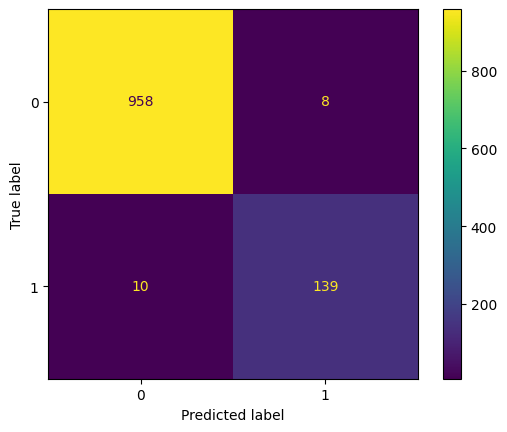

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, precision_recall_curve
emb_pred_threshold = (emb_pred >= 0.2).astype(int)
confusionM = confusion_matrix(y_test,emb_pred_threshold)
disp = ConfusionMatrixDisplay(confusionM)
disp.plot()
plt.show()

In [72]:
precision = precision_score(y_test,emb_pred_threshold)
recall = recall_score(y_test, emb_pred_threshold)
print(precision,recall)

0.9455782312925171 0.9328859060402684


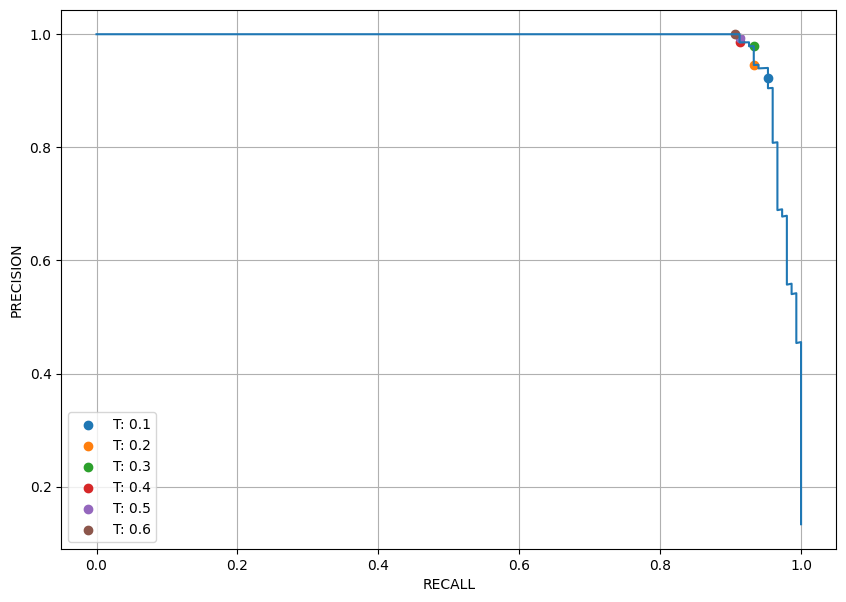

In [73]:
precision_prob, recall_prob, threshold = precision_recall_curve(y_test,emb_pred)
plt.figure(figsize=(10,7))
plt.plot(recall_prob,precision_prob)
plt.xlabel("RECALL")
plt.ylabel("PRECISION")
for t in [0.1,0.2,0.3,0.4,0.5,0.6]:
    indx = (threshold >= t).argmax()
    plt.scatter(recall_prob[indx],precision_prob[indx],label=f"T: {t}")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
emb_pred_threshold = emb_pred_threshold.reshape(-1,)
mis_indx = np.where(emb_pred_threshold != y_test)[0]
for i in mis_indx:
    print(f"Message : {x_test.iloc[i]}\nPredicted : {emb_pred_threshold[i]}\nTrue : {y_test.iloc[i]}\n{'--'*69}")
    

Message : IÛ÷ll have a look at the frying pan in case itÛ÷s cheap or a book perhaps. No thatÛ÷s silly a frying pan isnÛ÷t likely to be a book
Predicted : 1
True : 0
------------------------------------------------------------------------------------------------------------------------------------------
Message : Derp. Which is worse, a dude who always wants to party or a dude who files a complaint about the three drug abusers he lives with
Predicted : 1
True : 0
------------------------------------------------------------------------------------------------------------------------------------------
Message : ringtoneking 84484
Predicted : 0
True : 1
------------------------------------------------------------------------------------------------------------------------------------------
Message : Sorry I missed your call let's talk when you have the time. I'm on 07090201529
Predicted : 0
True : 1
---------------------------------------------------------------------------------------

In [75]:
x_train.head(10)

184                            Going on nothing great.bye
2171                        I wont. So wat's wit the guys
5422              Ok k..sry i knw 2 siva..tats y i askd..
4113    Where are you ? What do you do ? How can you s...
4588         Have you not finished work yet or something?
1581    Hhahhaahahah rofl wtf nig was leonardo in your...
3971                                        WOT U UP 2 J?
2701    Hiya, sorry didn't hav signal. I haven't seen ...
2755                                We r outside already.
1847    FREE NOKIA Or Motorola with upto 12mths 1/2pri...
Name: messages, dtype: object

In [76]:
for i in x_train_seq[:10]:
    print(i)

[73, 19, 327, 119, 1269]
[2, 348, 24, 1270, 666, 6, 423]
[49, 95, 1985, 2, 594, 22, 2534, 3847, 283, 2, 1024]
[116, 23, 4, 51, 28, 4, 28, 52, 29, 4, 1125, 3, 32, 493, 50, 11, 707, 14, 288, 1986, 390, 11, 98, 4, 1025, 16, 11, 98, 4, 931, 11]
[18, 4, 26, 538, 150, 257, 27, 181]
[3848, 1987, 1988, 3849, 63, 3850, 9, 14, 370, 27, 181]
[494, 7, 45, 22, 1440]
[1026, 81, 284, 558, 3851, 2, 495, 932, 27, 758, 50, 8, 2535, 121, 212, 10, 3852, 9, 1271, 79, 424, 19, 6, 811, 8, 34, 135, 3, 933, 15, 55, 3853, 8, 3854]
[39, 86, 631, 146]
[47, 204, 27, 866, 37, 3855, 2536, 133, 3856, 1989, 479, 47, 258, 595, 285, 3857, 3858, 47, 3859, 17, 759, 19, 1660, 27, 17, 1441, 3860]


In [77]:
for i in x_train_pad[:10]:
    print(i)

[  73   19  327  119 1269    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[   2  348   24 1270  666    6  423    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[  49   95 1985    2  594   22 2534 3847  283    2 1024    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[ 116   23    4   51   28    4   28   52   29    4 1125    3   32  493
   50   11  707   14  288 1986  390   11   98    4 1025   16   11   98
    4  931   11    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0  

LTSM
--

USING LTSM
-

- BEFORE
    - EMBEDDING --> FLATTEN --> DENSE

- AFTER
    - EMBEDDING --> LTSM --> DENSE

In [78]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [80]:
lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(64),
    Dense(1,activation='sigmoid')
])

In [81]:
lstm.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [82]:
lstm.fit(
    x_train_pad,
    y_train,
    batch_size = 32,
    epochs = 5,
    validation_split = 0.1
)

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9018 - loss: 0.3107 - val_accuracy: 0.9731 - val_loss: 0.1126
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9833 - loss: 0.0718 - val_accuracy: 0.9865 - val_loss: 0.0708
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9918 - loss: 0.0410 - val_accuracy: 0.9776 - val_loss: 0.0798
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9920 - loss: 0.0345 - val_accuracy: 0.9843 - val_loss: 0.0716
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9910 - loss: 0.0447 - val_accuracy: 0.9641 - val_loss: 0.1490


In [83]:
loss, accuracy = model.evaluate(x_test_pad,y_test)
print(accuracy,loss)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - accuracy: 0.9874 - loss: 0.0443
0.9874439239501953 0.04431992396712303


In [84]:
lstm_pred = model.predict(x_test_pad)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step


In [85]:
lstm_pred_threshold = (lstm_pred >= 0.2).astype(int)
lstm_pred_threshold

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(1115, 1))

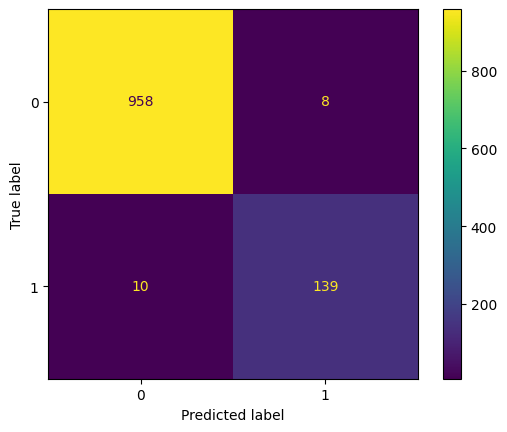

In [86]:
lstm_cm = confusion_matrix(y_test,lstm_pred_threshold)
disp = ConfusionMatrixDisplay(lstm_cm)
disp.plot()
plt.show()d

In [87]:
lstm_pred_threshold = lstm_pred_threshold.reshape(-1,)
mis_indx = np.where(lstm_pred_threshold != y_test)[0]
for i in mis_indx:
    print(f"Message : {x_test.iloc[i]}\nPredicted : {lstm_pred_threshold[i]}\nTrue : {y_test.iloc[i]}\n{'--'*69}")
    

Message : IÛ÷ll have a look at the frying pan in case itÛ÷s cheap or a book perhaps. No thatÛ÷s silly a frying pan isnÛ÷t likely to be a book
Predicted : 1
True : 0
------------------------------------------------------------------------------------------------------------------------------------------
Message : Derp. Which is worse, a dude who always wants to party or a dude who files a complaint about the three drug abusers he lives with
Predicted : 1
True : 0
------------------------------------------------------------------------------------------------------------------------------------------
Message : ringtoneking 84484
Predicted : 0
True : 1
------------------------------------------------------------------------------------------------------------------------------------------
Message : Sorry I missed your call let's talk when you have the time. I'm on 07090201529
Predicted : 0
True : 1
---------------------------------------------------------------------------------------